In [3]:
import os
import joblib
import pandas as pd

!pip install shap

import shap 
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 3.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 3.8 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 4.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
train = pd.read_csv('/Users/saidattaputta/Desktop/HomeValue-AI/data/processed/train_features.csv')

X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

processed = joblib.load('/Users/saidattaputta/Desktop/HomeValue-AI/artifacts/preprocessor.pkl')

X_train_processed = processed.transform(X_train)
X_test_processed = processed.transform(X_test)

final_tuned_model = joblib.load('/Users/saidattaputta/Desktop/HomeValue-AI/models/best_model.pkl')

In [9]:
shap.initjs()

In [10]:
explainer = shap.LinearExplainer(final_tuned_model,X_train_processed)
shap_values = explainer(X_test_processed)

Background dataset has 1069 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1069 when initializing the masker.


In [13]:
feature_names = processed.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

explainer = shap.LinearExplainer(final_tuned_model, X_train_processed)
shap_values = explainer(X_test_processed)
print(len(feature_names))

Background dataset has 1069 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1069 when initializing the masker.


243


In [16]:
# 1. Extract post-transformation feature names from the pipeline AND convert to a list
feature_names = processed.get_feature_names_out().tolist()

# 2. Attach these clean names directly to your computed SHAP values object
shap_values.feature_names = feature_names

print(f"🏷️ Feature names mapped successfully!")
print(f"Total features tracked in the model space: {len(feature_names)}")

KeyError: 'num__Id'

In [17]:
# 1. Load your feature-engineered data
df = pd.read_csv("/Users/saidattaputta/Desktop/HomeValue-AI/data/processed/train_features.csv")

# 2. Separate features (X) and target variable (y) - DROP THE ID COLUMN!
X = df.drop(["SalePrice", "Id"], axis=1, errors='ignore')
y = df["SalePrice"]

# 3. Re-run your split and processing steps
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = processed.transform(X_train)
X_test_processed = processed.transform(X_test)

ValueError: columns are missing: {'Id'}

In [19]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# 1. Load data and keep 'Id' so the transformer doesn't panic
df = pd.read_csv("/Users/saidattaputta/Desktop/HomeValue-AI/data/processed/train_features.csv")
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Load preprocessor and transform
preprocessor = joblib.load("/Users/saidattaputta/Desktop/HomeValue-AI/artifacts/preprocessor.pkl")
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 3. Re-calculate your SHAP explainer values
explainer = shap.LinearExplainer(final_tuned_model, X_train_processed)
shap_values = explainer(X_test_processed)

Background dataset has 1069 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1069 when initializing the masker.


In [20]:
# 1. Extract feature names as a standard Python list
feature_names = preprocessor.get_feature_names_out().tolist()

# 2. Attach them to the SHAP object safely
shap_values.feature_names = feature_names

# 3. Cleanly remove the 'num__Id' feature from the SHAP display matrix 
if 'num__Id' in shap_values.feature_names:
    id_index = shap_values.feature_names.index('num__Id')
    # Filter out the Id index from the SHAP dimensions
    shap_values = shap_values[:, [i for i in range(shap_values.shape[1]) if i != id_index]]
    print("🧹 Successfully removed 'num__Id' from the SHAP analysis space.")

print(f"🏷️ Feature names mapped successfully! Total features tracked: {len(shap_values.feature_names)}")

🧹 Successfully removed 'num__Id' from the SHAP analysis space.
🏷️ Feature names mapped successfully! Total features tracked: 242


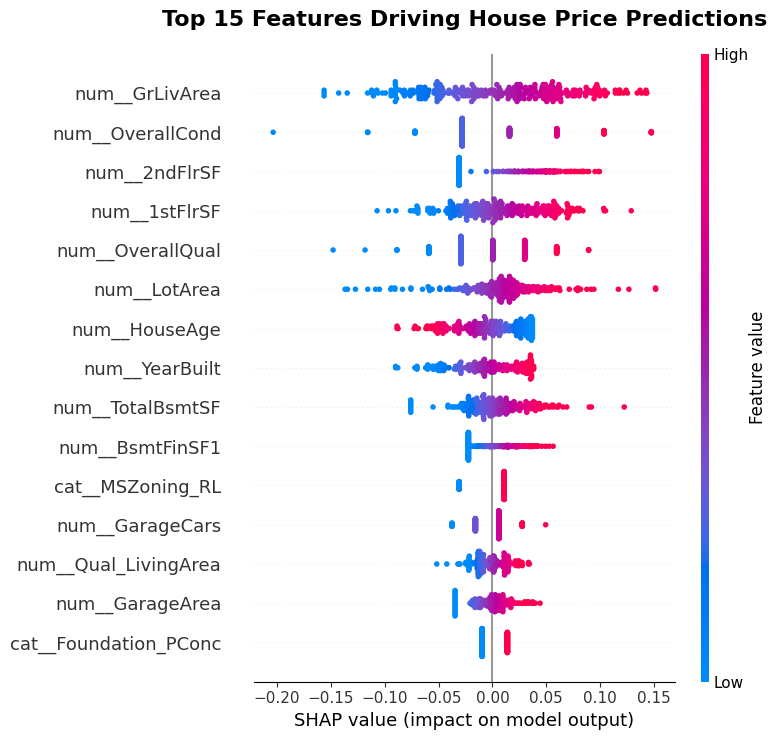

In [25]:
import matplotlib.pyplot as plt
import shap

# 1. Set up the plotting environment size
plt.figure(figsize=(12, 8))

# 2. Create the beeswarm summary plot 
# We look at the top 15 most influential features
shap.summary_plot(shap_values, max_display=15, show=False)

# 3. Clean up titles and display cleanly
plt.title("Top 15 Features Driving House Price Predictions", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
plt.savefig("../artifacts/shap_global_summary.png")

<Figure size 640x480 with 0 Axes>

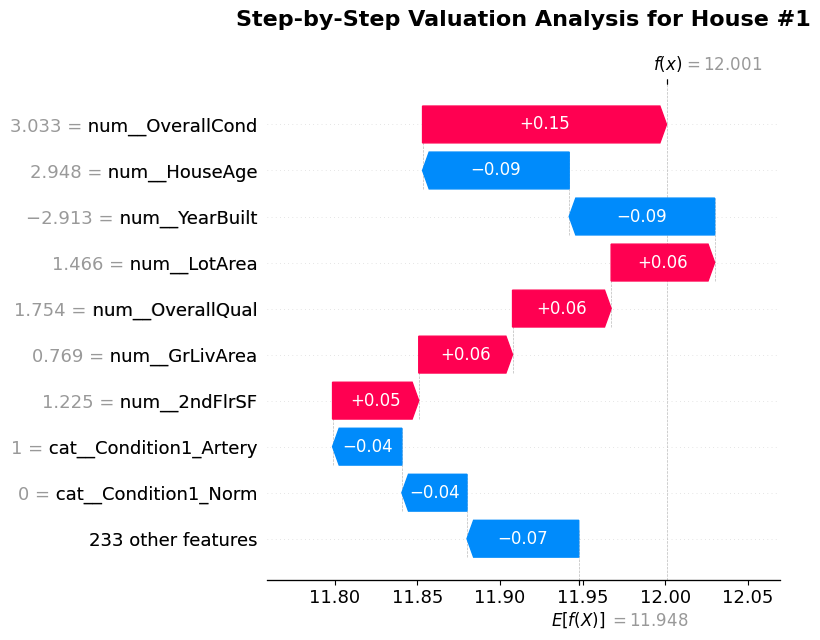

In [26]:
single_house_explanation = shap_values[0]

plt.figure(figsize=(12,8))

shap.plots.waterfall(single_house_explanation,max_display=10,show=False)
plt.title("Step-by-Step Valuation Analysis for House #1", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
plt.savefig("../artifacts/shap_local_waterfall.png")

In [24]:
import os
import joblib

os.makedirs('../artifacts',exist_ok=True)

joblib.dump(shap_values,'../artifacts/shap_values.pkl')

['../artifacts/shap_values.pkl']